<a href="https://colab.research.google.com/github/aronalva12/analisis-pasaportes-2026/blob/main/An%C3%A1lisis_de_datos_de_Bitel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib as plt

lectura de datos :

In [ ]:

# Lee el archivo especificando la hoja y la fila del encabezado (header=3)
informacion = pd.read_excel(
    r"/content/8.1. PORTABILIDAD MÓVIL.xlsx", sheet_name="Dataset", header=3)
# Muestra las primeras filas para verificar que cargó bien
informacion.head()

In [ ]:
informacion.isnull().sum() #Detectar cantidad de nulos en una lista de valores

In [ ]:
# Convierte la columna Mes a formato fecha (si aún no lo está) y crea la columna 'Año'
informacion["Año"] = pd.to_datetime(informacion["Mes"]).dt.year

# Muestra las primeras filas para confirmar que se agregó correctamente
informacion.head()

,Unnamed: 0,Cedente,Receptor,Modalidad Cedente,Modalidad Receptor,Mes,Líneas,Año
0,NaN,América Móvil Perú S.A.C.,Entel Perú S.A.,PREPAGO,PREPAGO,2014-07-01,112,2014
1,NaN,América Móvil Perú S.A.C.,Telefónica del Perú S.A.A.,PREPAGO,PREPAGO,2014-07-01,162,2014
2,NaN,Entel Perú S.A.,América Móvil Perú S.A.C.,PREPAGO,PREPAGO,2014-07-01,35,2014
3,NaN,Entel Perú S.A.,Telefónica del Perú S.A.A.,PREPAGO,PREPAGO,2014-07-01,18,2014
4,NaN,Telefónica del Perú S.A.A.,América Móvil Perú S.A.C.,PREPAGO,PREPAGO,2014-07-01,601,2014


In [ ]:
bitel = informacion[informacion["Receptor"] == "Viettel Perú S.A.C."]
print(bitel)

In [ ]:
informacion['Receptor'].unique() #Ver la lista de receptores de compañias

array(['Entel Perú S.A.', 'Telefónica del Perú S.A.A.',
       'América Móvil Perú S.A.C.', 'Viettel Perú S.A.C.',
       'Flash Servicios Perú S.R.L.', 'Dolphin Telecom del Perú S.AC.',
       'Guinea Mobile S.A.C.', 'Suma Móvil Perú S.A.C.',
       'Dolphin Mobile S.A.C.', 'Integratel Perú S.A.A.'], dtype=object)

In [ ]:
agrupados = bitel.groupby(["Año", "Modalidad Cedente"])["Líneas"].sum()
print(agrupados)

In [37]:
import matplotlib.pyplot as plt

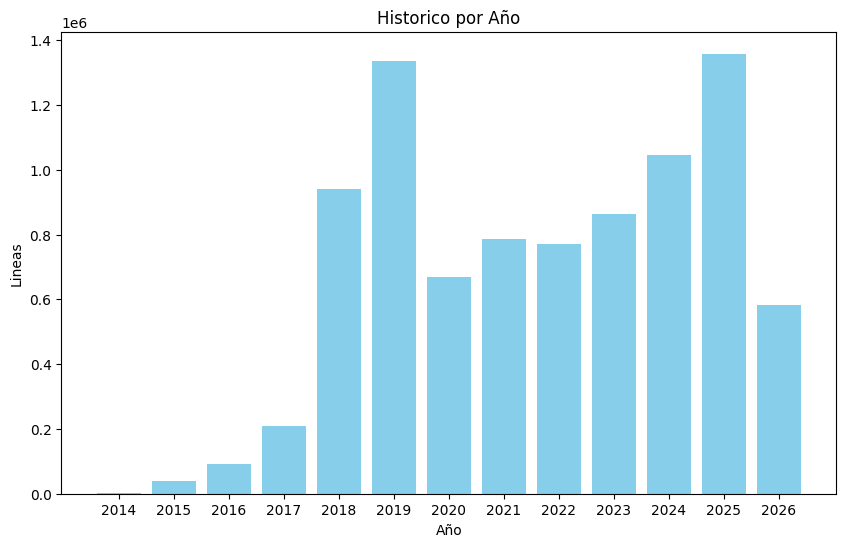

In [51]:
agrupados = bitel.groupby("Año")["Líneas"].sum()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(agrupados.index.astype(str), agrupados.values, color="skyblue")

ax.set_title("Historico por Año")
ax.set_xlabel("Año")
ax.set_ylabel("Lineas")

plt.show()